In [93]:
import numpy as np

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## READ DATA

In [95]:
df = pd.read_csv('ultimate_student_productivity_dataset_5000.csv')
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


## DATA ANALTSIS

In [96]:
df.describe(include='all')

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
unique,NaN,NaN,3,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Male,Postgraduate,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Good,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1719,1687,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1722,NaN,NaN,NaN,NaN,NaN
mean,2500.500000,20.520400,NaN,NaN,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,...,74.535600,251.450400,0.498200,0.501400,NaN,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,NaN,NaN,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,...,42.932293,143.842712,0.500047,0.500048,NaN,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,NaN,NaN,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,...,37.000000,129.000000,0.000000,0.000000,NaN,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,NaN,NaN,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,...,75.000000,252.000000,0.000000,1.000000,NaN,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,NaN,NaN,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,...,112.000000,376.000000,1.000000,1.000000,NaN,8.000000,36.242500,55.352500,49.142500,27.400000


In [97]:
df.isnull().sum()

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

In [98]:
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [99]:
df['academic_level'].unique()

<StringArray>
['High School', 'Undergraduate', 'Postgraduate']
Length: 3, dtype: str

In [100]:
df['gender'].unique()

<StringArray>
['Other', 'Male', 'Female']
Length: 3, dtype: str

In [101]:
education_mapping = {
    'High School': 0,
    'Undergraduate': 1,
    'Postgraduate': 2
}

df['academic_level'] = df['academic_level'].map(education_mapping)

In [102]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

In [103]:
df['internet_quality'].unique()

<StringArray>
['Good', 'Poor', 'Average']
Length: 3, dtype: str

In [104]:
df['internet_quality'] = df['internet_quality'].map({
    'Good':0,
    'Poor':1,
    'Average':2,
})

In [105]:
df.head()

,student_id,age,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,...,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score,gender_Male,gender_Other
0,1,18,0,7.64,1.56,2.20,3.05,2.19,6.52,6.47,...,1,0,0,10,43.05,31.77,73.65,50.16,False,True
1,2,18,0,2.21,2.22,2.10,1.65,2.55,5.97,6.05,...,0,0,0,3,15.92,37.00,13.70,1.00,False,True
2,3,22,0,3.45,0.00,0.29,1.34,2.08,8.39,7.62,...,0,1,0,8,27.39,34.37,45.15,18.30,True,False
3,4,17,0,5.75,2.08,3.01,2.27,2.20,6.31,11.67,...,1,1,1,3,22.31,77.31,20.92,9.37,False,True
4,5,19,0,6.83,1.72,3.33,2.65,0.70,8.01,10.02,...,1,0,0,8,38.11,39.53,59.23,27.81,False,True


## Visualizations

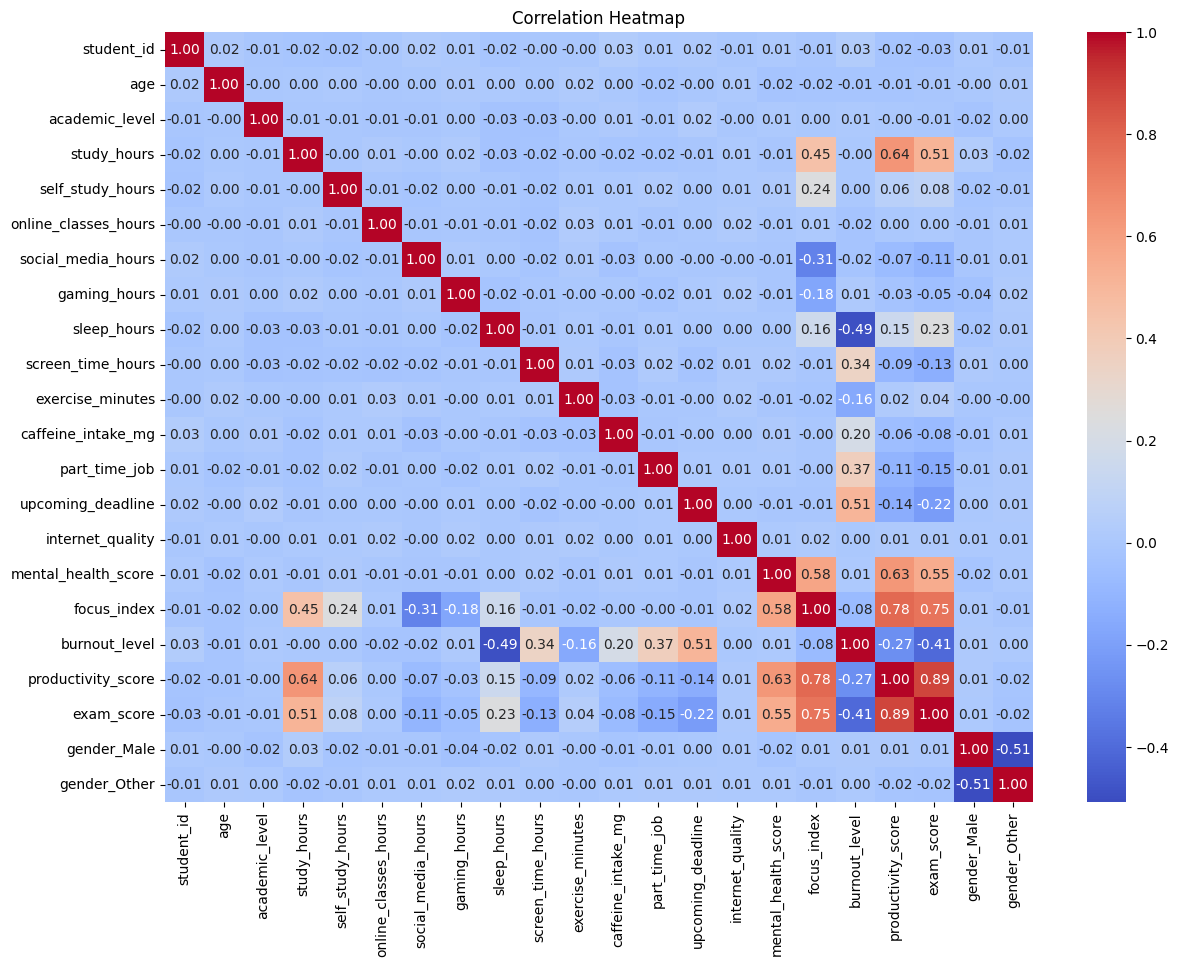

In [106]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

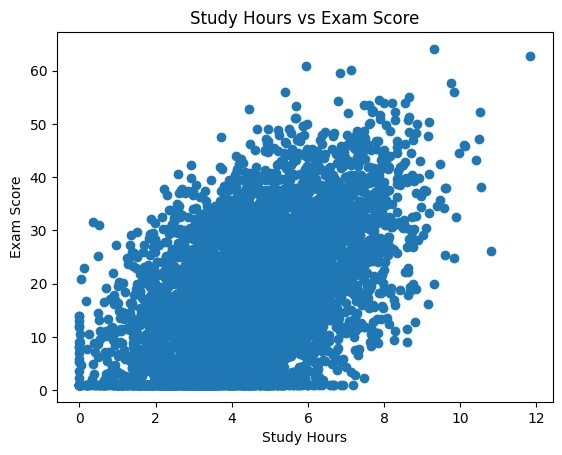

In [112]:
plt.figure()
plt.scatter(df["study_hours"], df["exam_score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()

## FEATURE SELECTION

In [107]:
y = df['exam_score']
X = df.drop(columns=["student_id", "exam_score"])

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [109]:
model = LinearRegression()

In [110]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [111]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 25.016544930029887
R² Score: 0.8164058190523703
